In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('../data/인구현황.csv')

df = df[df['행정기관'] != '전국'].copy()

df.head()

,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97


In [9]:
top5_population = df.sort_values('총인구수', ascending=False).head(5)

top5_population[['행정기관', '총인구수']]

,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


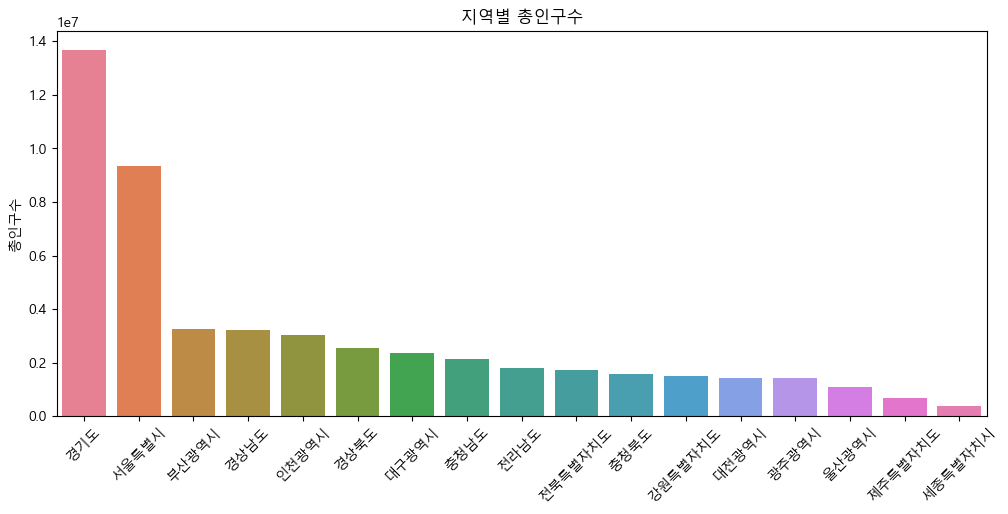

In [19]:
population_sorted = df.sort_values('총인구수', ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=population_sorted,
    x='행정기관',
    y='총인구수',
    hue='행정기관',
    palette='husl',
    legend=False
)

plt.title('지역별 총인구수')
plt.xlabel('')
plt.ylabel('총인구수')
plt.xticks(rotation=45)

plt.show()

In [11]:
top5_household = (
    df.sort_values('세대당 인구', ascending=False)
      .head(5)
      .reset_index(drop=True)
)

top5_household[['행정기관', '세대당 인구']]

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


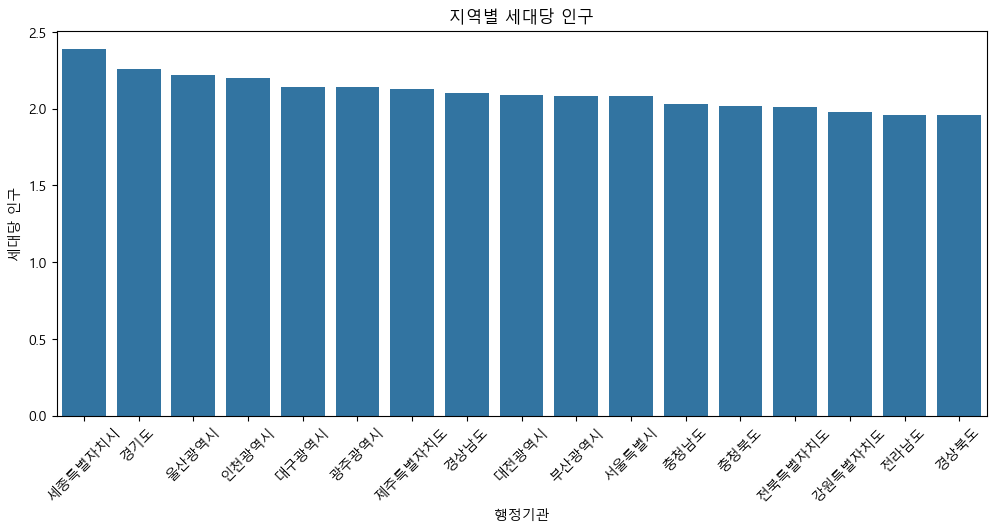

In [ ]:
household_sorted = df.sort_values('세대당 인구', ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=household_sorted,
    x='행정기관',
    y='세대당 인구',
    hue='행정기관',
    palette='husl',
    legend=False
)

plt.title('지역별 세대당 인구')
plt.xlabel('행정기관')
plt.ylabel('세대당 인구')
plt.xticks(rotation=45)

plt.show()

In [13]:
gender_ratio = (
    df[['행정기관', '남여 비율']]
    .sort_values('남여 비율', ascending=False)
    .reset_index(drop=True)
)

gender_ratio

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


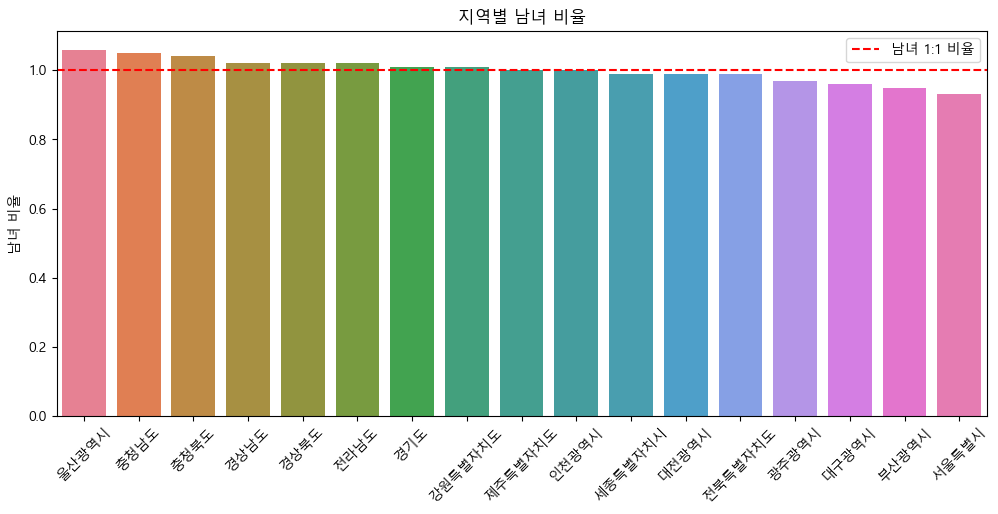

In [21]:
gender_sorted = df.sort_values('남여 비율', ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=gender_sorted,
    x='행정기관',
    y='남여 비율',
    hue='행정기관',
    palette='husl',
    legend=False
)

plt.axhline(
    y=1.0,
    color='red',
    linestyle='--',
    label='남녀 1:1 비율'
)

plt.title('지역별 남녀 비율')
plt.xlabel('')
plt.ylabel('남녀 비율')
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [15]:
def gender_type(ratio):
    if ratio > 1:
        return '남초'
    elif ratio < 1:
        return '여초'
    else:
        return '동일'

df['남초여초'] = df['남여 비율'].apply(gender_type)

df[['행정기관', '남여 비율', '남초여초']]

,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


In [16]:
household_mean = df['세대당 인구'].mean()

print(f'전국 평균 세대당 인구수: {household_mean:.2f}')

above_mean = (
    df[df['세대당 인구'] > household_mean]
    .sort_values('세대당 인구', ascending=False)
    .reset_index(drop=True)
)

above_mean[['행정기관', '세대당 인구']]

전국 평균 세대당 인구수: 2.11


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


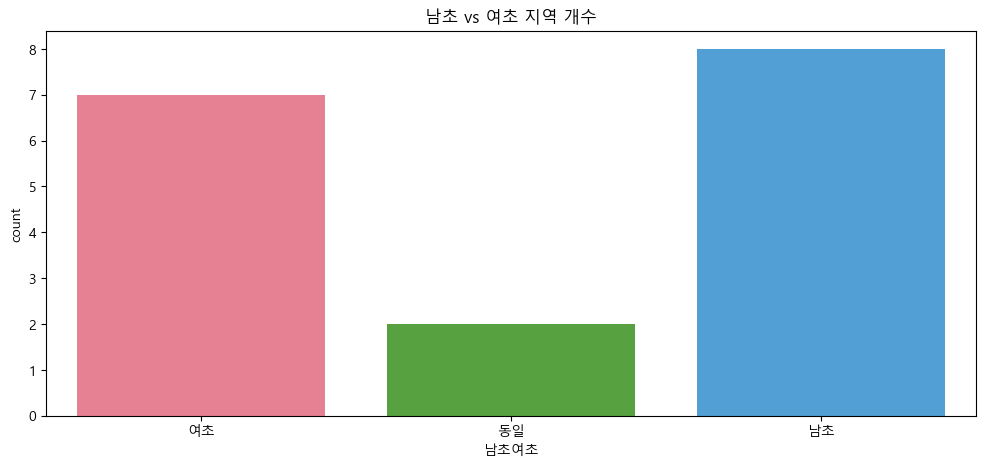

In [22]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x='남초여초',
    order=['여초', '동일', '남초'],
    hue='남초여초',
    palette='husl',
    legend=False
)

plt.title('남초 vs 여초 지역 개수')
plt.xlabel('남초여초')
plt.ylabel('count')

plt.show()

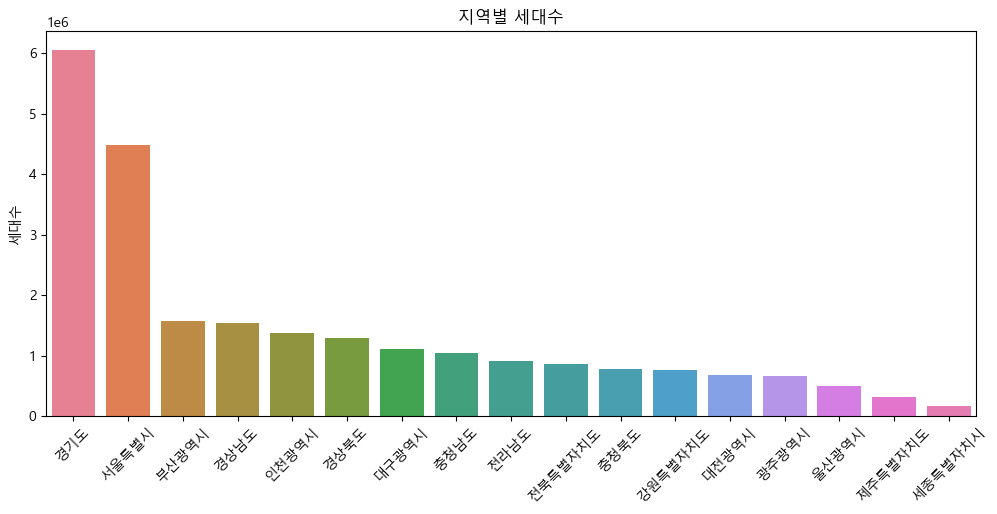

In [23]:
household_count_sorted = df.sort_values('세대수', ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=household_count_sorted,
    x='행정기관',
    y='세대수',
    hue='행정기관',
    palette='husl',
    legend=False
)

plt.title('지역별 세대수')
plt.xlabel('')
plt.ylabel('세대수')
plt.xticks(rotation=45)

plt.show()